# Статистическая проверка гипотезы 2. Stochastic RPML + CVaR.

Данный ноутбук предназначен для проверки гипотезы о снижении риска кассового разрыва при переходе от детерминистической RPML к стохастической постановке с `CVaR`.

**Формулировка гипотезы 2:**
Если расширить детерминистическую RPML-модель до стохастической постановки со сценариями дохода и оптимизацией вида `min cost + λ * CVaR`, а также ограничить частоту кассового разрыва условием `Cash Shortfall Rate <= beta`, то можно получить более устойчивый план выплат и снизить риск кассового разрыва.

**Основные метрики:**
- `CVaR shortfall`
- `Cash Shortfall Rate`
- `Total payment cost` как цена устойчивости.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

## 1. Загрузка результатов H2

Ноутбук поддерживает два источника:
- агрегированный CSV (`stochastic_cvar/stochastic_cvar_results.csv`),
- checkpoint JSONL (`checkpoint/stochastic_cvar_experiment_results_checkpoint.jsonl`).

Ниже по умолчанию указан крупный run для постановки `min cost + λ * CVaR` при ограничении `Cash Shortfall Rate <= beta`.

Если `RUN_ID` не задан, выбирается самый свежий run с артефактами H2.

In [2]:
RUNS_ROOT = Path("tmp/runs")
RUN_ID: str | None = "20260404-092409_base_h2cvar_n4_tl300_m110_a95_l1p0_b0p5_54eeda9a"


def _artifact_paths(run_dir: Path) -> tuple[Path, Path]:
    csv_path = run_dir / "stochastic_cvar" / "stochastic_cvar_results.csv"
    checkpoint_path = run_dir / "checkpoint" / "stochastic_cvar_experiment_results_checkpoint.jsonl"
    return csv_path, checkpoint_path


def _run_has_h2_artifacts(run_dir: Path) -> bool:
    csv_path, checkpoint_path = _artifact_paths(run_dir)
    return csv_path.exists() or checkpoint_path.exists()


def resolve_h2_run_dir(runs_root: Path, run_id: str | None = None) -> Path:
    if run_id:
        run_dir = runs_root / run_id
        if not run_dir.exists():
            raise FileNotFoundError(f"Run not found: {run_dir}")
        if not _run_has_h2_artifacts(run_dir):
            raise FileNotFoundError(f"No H2 artifacts in run: {run_dir}")
        return run_dir

    candidates = [d for d in runs_root.iterdir() if d.is_dir() and _run_has_h2_artifacts(d)]
    if not candidates:
        raise FileNotFoundError(f"No H2 runs found in: {runs_root}")
    candidates.sort(key=lambda d: d.stat().st_mtime, reverse=True)
    return candidates[0]


def _load_h2_from_checkpoint(path: Path) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    if not rows:
        raise ValueError(f"Checkpoint is empty: {path}")
    return pd.DataFrame(rows)


def load_h2_results(run_dir: Path) -> pd.DataFrame:
    csv_path, checkpoint_path = _artifact_paths(run_dir)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    if checkpoint_path.exists():
        return _load_h2_from_checkpoint(checkpoint_path)
    raise FileNotFoundError(f"No H2 results found in run: {run_dir}")


RUN_DIR = resolve_h2_run_dir(RUNS_ROOT, RUN_ID)
df_h2 = load_h2_results(RUN_DIR)

print(f"Используется run: {RUN_DIR.name}")
print(f"Строк в наборе H2: {len(df_h2)}")
if "shortfall_rate_beta" in df_h2.columns:
    print(f"beta: {sorted(pd.Series(df_h2['shortfall_rate_beta']).dropna().unique().tolist())}")
print("\nКолонки:")
print(sorted(df_h2.columns))

Используется run: 20260404-092409_base_h2cvar_n4_tl300_m110_a95_l1p0_b0p5_54eeda9a
Строк в наборе H2: 110
beta: [0.5]

Колонки:
['delta_cash_shortfall_rate', 'delta_cvar_shortfall', 'delta_total_payment_cost', 'deterministic_cash_shortfall_rate', 'deterministic_cost', 'deterministic_cvar_shortfall', 'deterministic_gap', 'deterministic_max_shortfall', 'deterministic_mean_shortfall', 'deterministic_median_shortfall', 'deterministic_p90_shortfall', 'deterministic_solve_time', 'deterministic_status', 'instance_name', 'n_loans', 'n_scenarios', 'risk_alpha', 'risk_lambda', 'shortfall_epsilon', 'shortfall_rate_beta', 'stochastic_cash_shortfall_rate', 'stochastic_cvar_shortfall', 'stochastic_gap', 'stochastic_max_shortfall', 'stochastic_mean_shortfall', 'stochastic_median_shortfall', 'stochastic_objective_value', 'stochastic_p90_shortfall', 'stochastic_solve_time', 'stochastic_status', 'stochastic_total_payment_cost']


## 2. Подготовка данных и описательная статистика

Сначала выводится операционная сводка всего прогона в логике CLI summary.

Затем для статистических тестов используется только подвыборка, где и deterministic, и stochastic решение имеют статус `OPTIMAL`.

Статусы `FEASIBLE` сохраняются в ноутбуке только как диагностическая информация о solver coverage, но не используются для headline-сравнения и статистических выводов.

Важно: при неполном solver coverage статистические выводы относятся именно к `OPTIMAL`-подвыборке, а не ко всем базовым инстансам.

In [3]:
VALID_STATUSES = {"OPTIMAL", "FEASIBLE"}

required_cols = [
    "deterministic_status",
    "stochastic_status",
    "deterministic_cvar_shortfall",
    "stochastic_cvar_shortfall",
    "deterministic_cash_shortfall_rate",
    "stochastic_cash_shortfall_rate",
    "stochastic_total_payment_cost",
]

missing = [c for c in required_cols if c not in df_h2.columns]
if missing:
    raise ValueError(f"В результатах отсутствуют колонки: {missing}")

det_cost_col = (
    "deterministic_total_payment_cost"
    if "deterministic_total_payment_cost" in df_h2.columns
    else "deterministic_cost"
)
if det_cost_col not in df_h2.columns:
    raise ValueError("Не найдена колонка детерминистической стоимости: deterministic_total_payment_cost/deterministic_cost")

if "delta_cvar_shortfall" not in df_h2.columns:
    df_h2["delta_cvar_shortfall"] = (
        df_h2["stochastic_cvar_shortfall"] - df_h2["deterministic_cvar_shortfall"]
    )
if "delta_cash_shortfall_rate" not in df_h2.columns:
    df_h2["delta_cash_shortfall_rate"] = (
        df_h2["stochastic_cash_shortfall_rate"] - df_h2["deterministic_cash_shortfall_rate"]
    )
if "delta_total_payment_cost" not in df_h2.columns:
    df_h2["delta_total_payment_cost"] = (
        df_h2["stochastic_total_payment_cost"] - df_h2[det_cost_col]
    )

df_diagnostic_usable = df_h2[
    df_h2["deterministic_status"].isin(VALID_STATUSES)
    & df_h2["stochastic_status"].isin(VALID_STATUSES)
].copy()

df_usable = df_h2[
    (df_h2["deterministic_status"] == "OPTIMAL")
    & (df_h2["stochastic_status"] == "OPTIMAL")
].copy()

df_nonusable = df_h2.loc[~df_h2.index.isin(df_usable.index)].copy()


def finite_summary(series: pd.Series) -> tuple[float, float, int]:
    arr = series.to_numpy(dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return float("nan"), float("nan"), 0
    return float(np.mean(arr)), float(np.median(arr)), int(arr.size)


total_rows = len(df_h2)
det_optimal_count = int((df_h2["deterministic_status"] == "OPTIMAL").sum())
stoch_optimal_count = int((df_h2["stochastic_status"] == "OPTIMAL").sum())
det_usable_count = int(df_h2["deterministic_status"].isin(VALID_STATUSES).sum())
stoch_usable_count = int(df_h2["stochastic_status"].isin(VALID_STATUSES).sum())

print("Операционная сводка прогона:")
print(f"Всего строк: {total_rows}")
print(f"Deterministic OPTIMAL coverage: {det_optimal_count}/{total_rows} ({det_optimal_count / max(total_rows, 1):.1%})")
print(f"Stochastic OPTIMAL coverage: {stoch_optimal_count}/{total_rows} ({stoch_optimal_count / max(total_rows, 1):.1%})")
print(f"Deterministic usable coverage: {det_usable_count}/{total_rows} ({det_usable_count / max(total_rows, 1):.1%})")
print(f"Stochastic usable coverage: {stoch_usable_count}/{total_rows} ({stoch_usable_count / max(total_rows, 1):.1%})")
print(f"Comparable OPTIMAL subset: {len(df_usable)}/{total_rows} ({len(df_usable) / max(total_rows, 1):.1%})")

if "shortfall_rate_beta" in df_h2.columns and not df_h2["shortfall_rate_beta"].dropna().empty:
    beta_value = float(df_h2["shortfall_rate_beta"].dropna().iloc[0])
    print(f"Shortfall rate beta: {beta_value:.3f}")
else:
    beta_value = None

for col in ["delta_cvar_shortfall", "delta_cash_shortfall_rate", "delta_total_payment_cost"]:
    mean_val, median_val, finite_count = finite_summary(df_usable[col])
    print(f"{col}: avg {mean_val:.4f}, median {median_val:.4f}, finite_n={finite_count}")

print("\nДиагностика usable-подвыборки:")
print(f"OPTIMAL+FEASIBLE строк: {len(df_diagnostic_usable)}")
print(f"Покрытие usable-подвыборки: {len(df_diagnostic_usable) / max(total_rows, 1):.1%}")

loan_count_col = "loan_count" if "loan_count" in df_usable.columns else "n_loans" if "n_loans" in df_usable.columns else None
if loan_count_col is not None:
    print("\nРазбивка по количеству долгов в OPTIMAL-подвыборке:")
    print(df_usable[loan_count_col].value_counts().sort_index().to_string())

if beta_value is not None and len(df_usable) > 0:
    print(f"\nМаксимальный stochastic Cash Shortfall Rate в OPTIMAL-подвыборке: {df_usable['stochastic_cash_shortfall_rate'].max():.3f}")
    print(
        "Количество OPTIMAL-решений, где ограничение активно (rate == beta): "
        f"{int(np.sum(np.isclose(df_usable['stochastic_cash_shortfall_rate'], beta_value)))}"
    )

print("\nСводка статусов stochastic-решения:")
print(df_h2["stochastic_status"].value_counts().to_string())

if len(df_nonusable) > 0:
    print("\nСтроки вне OPTIMAL-подвыборки:")
    display(df_nonusable[["instance_name", "deterministic_status", "stochastic_status"]])

display(
    df_usable[
        [
            "delta_cvar_shortfall",
            "delta_cash_shortfall_rate",
            "delta_total_payment_cost",
        ]
    ].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
)

Операционная сводка прогона:
Всего строк: 110
Deterministic OPTIMAL coverage: 109/110 (99.1%)
Stochastic OPTIMAL coverage: 52/110 (47.3%)
Deterministic usable coverage: 110/110 (100.0%)
Stochastic usable coverage: 80/110 (72.7%)
Comparable OPTIMAL subset: 52/110 (47.3%)
Shortfall rate beta: 0.500
delta_cvar_shortfall: avg -104269.9254, median -76455.1091, finite_n=52
delta_cash_shortfall_rate: avg -0.3341, median -0.3125, finite_n=52
delta_total_payment_cost: avg 40011.6438, median 22732.4668, finite_n=52

Диагностика usable-подвыборки:
OPTIMAL+FEASIBLE строк: 80
Покрытие usable-подвыборки: 72.7%

Разбивка по количеству долгов в OPTIMAL-подвыборке:
n_loans
4    52

Максимальный stochastic Cash Shortfall Rate в OPTIMAL-подвыборке: 0.500
Количество OPTIMAL-решений, где ограничение активно (rate == beta): 33

Сводка статусов stochastic-решения:
stochastic_status
OPTIMAL       52
FEASIBLE      28
NOT_SOLVED    18
INFEASIBLE    12

Строки вне OPTIMAL-подвыборки:


,instance_name,deterministic_status,stochastic_status
30,Deudas_4_0_2_0_2_120_fijo_fijo_0,OPTIMAL,FEASIBLE
31,Deudas_4_0_2_0_2_120_fijo_fijo_1,OPTIMAL,FEASIBLE
32,Deudas_4_0_2_0_2_120_fijo_fijo_2,OPTIMAL,FEASIBLE
34,Deudas_4_0_2_0_2_120_fijo_fijo_4,OPTIMAL,INFEASIBLE
36,Deudas_4_0_2_0_2_120_fijo_fijo_6,OPTIMAL,FEASIBLE
37,Deudas_4_0_2_0_2_120_fijo_fijo_7,OPTIMAL,FEASIBLE
38,Deudas_4_0_2_0_2_120_fijo_fijo_8,OPTIMAL,FEASIBLE
39,Deudas_4_0_2_0_2_120_fijo_fijo_9,OPTIMAL,FEASIBLE
41,Deudas_4_0_2_2_0_120_fijo_fijo_1,OPTIMAL,INFEASIBLE
42,Deudas_4_0_2_2_0_120_fijo_fijo_2,OPTIMAL,FEASIBLE


,delta_cvar_shortfall,delta_cash_shortfall_rate,delta_total_payment_cost
count,52.000000,52.000000,52.000000
mean,-104269.925360,-0.334135,40011.643769
std,125845.478622,0.246726,56268.194823
min,-677752.273256,-0.968750,-1706.790628
10%,-198869.265763,-0.687500,2841.805634
25%,-129801.690840,-0.406250,11924.627386
50%,-76455.109106,-0.312500,22732.466841
75%,-21436.603888,-0.218750,41442.852916
90%,-4544.304231,-0.093750,72061.736547
max,72.628373,0.406250,250280.499700


## 3. Визуальный анализ

Отрицательное значение `delta` означает, что стохастическая модель лучше по соответствующей метрике.

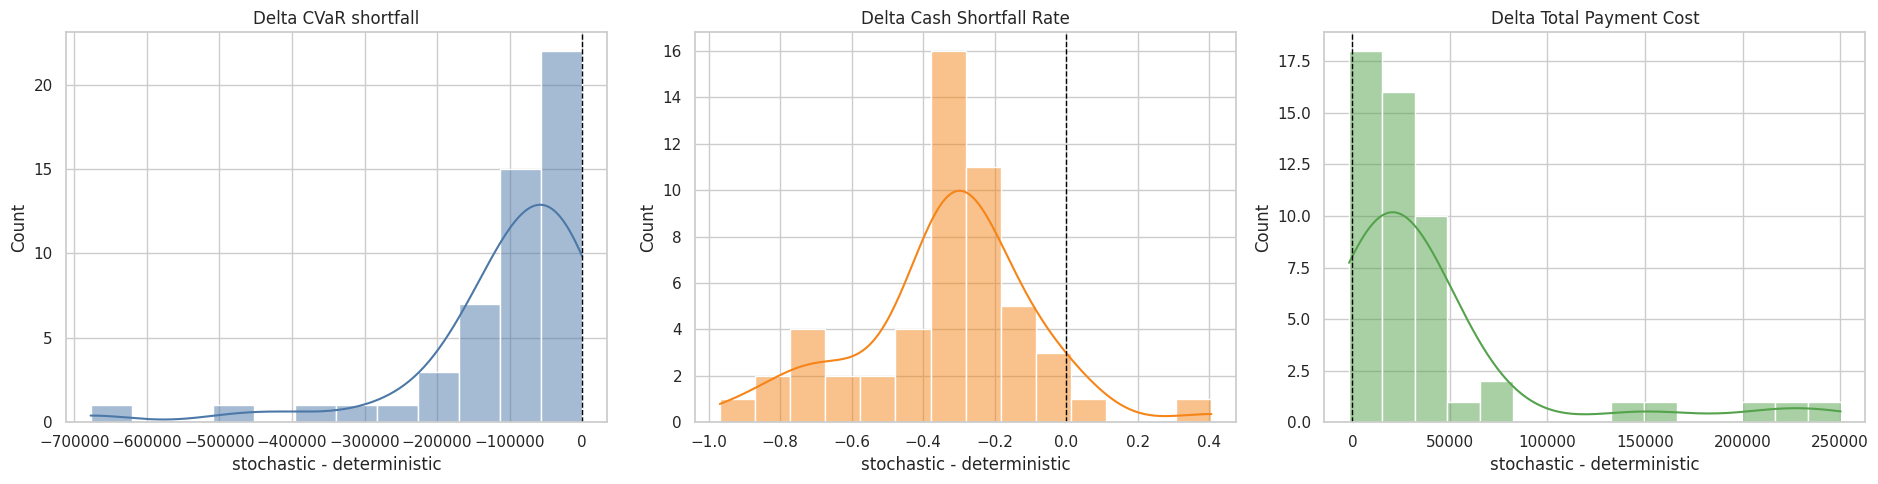

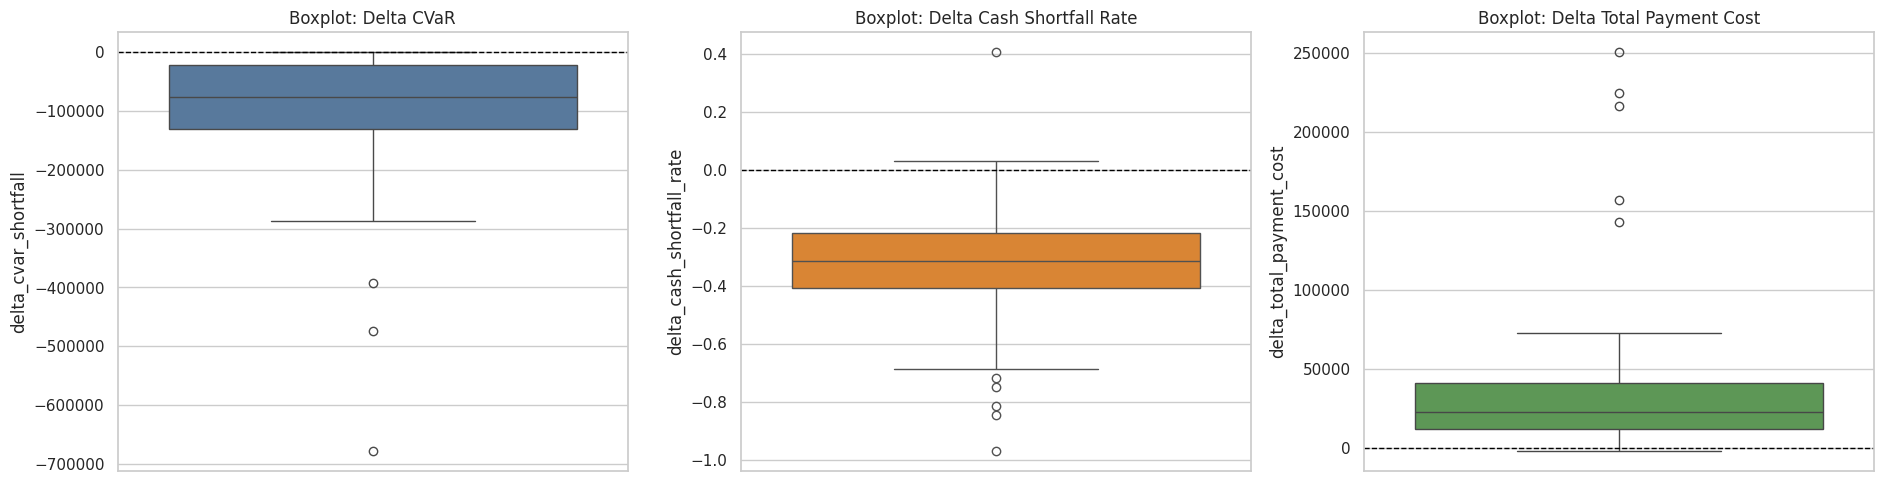

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.histplot(df_usable["delta_cvar_shortfall"], kde=True, ax=axes[0], color="#4c78a8")
axes[0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Delta CVaR shortfall")
axes[0].set_xlabel("stochastic - deterministic")

sns.histplot(df_usable["delta_cash_shortfall_rate"], kde=True, ax=axes[1], color="#f58518")
axes[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Delta Cash Shortfall Rate")
axes[1].set_xlabel("stochastic - deterministic")

sns.histplot(df_usable["delta_total_payment_cost"], kde=True, ax=axes[2], color="#54a24b")
axes[2].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Delta Total Payment Cost")
axes[2].set_xlabel("stochastic - deterministic")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.boxplot(y=df_usable["delta_cvar_shortfall"], ax=axes[0], color="#4c78a8")
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Boxplot: Delta CVaR")

sns.boxplot(y=df_usable["delta_cash_shortfall_rate"], ax=axes[1], color="#f58518")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Boxplot: Delta Cash Shortfall Rate")

sns.boxplot(y=df_usable["delta_total_payment_cost"], ax=axes[2], color="#54a24b")
axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Boxplot: Delta Total Payment Cost")

plt.tight_layout()
plt.show()

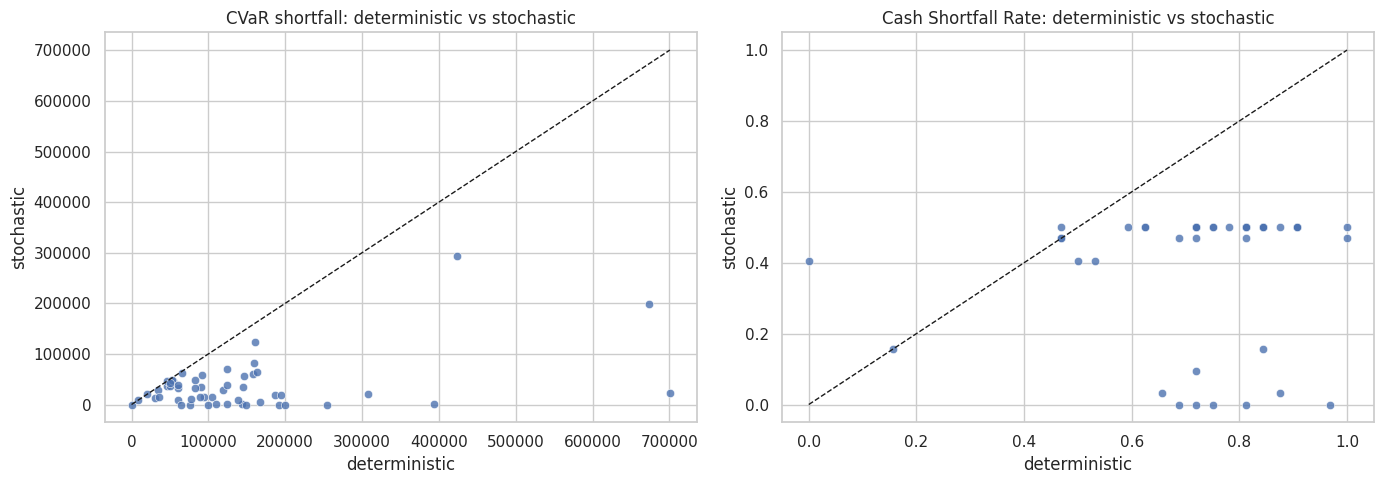

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_usable,
    x="deterministic_cvar_shortfall",
    y="stochastic_cvar_shortfall",
    ax=axes[0],
    alpha=0.8,
)
max_cvar = float(
    max(df_usable["deterministic_cvar_shortfall"].max(), df_usable["stochastic_cvar_shortfall"].max())
)
axes[0].plot([0, max_cvar], [0, max_cvar], "k--", linewidth=1)
axes[0].set_title("CVaR shortfall: deterministic vs stochastic")
axes[0].set_xlabel("deterministic")
axes[0].set_ylabel("stochastic")

sns.scatterplot(
    data=df_usable,
    x="deterministic_cash_shortfall_rate",
    y="stochastic_cash_shortfall_rate",
    ax=axes[1],
    alpha=0.8,
)
max_rate = float(
    max(
        df_usable["deterministic_cash_shortfall_rate"].max(),
        df_usable["stochastic_cash_shortfall_rate"].max(),
    )
)
axes[1].plot([0, max_rate], [0, max_rate], "k--", linewidth=1)
axes[1].set_title("Cash Shortfall Rate: deterministic vs stochastic")
axes[1].set_xlabel("deterministic")
axes[1].set_ylabel("stochastic")

plt.tight_layout()
plt.show()

## 4. Статистическое тестирование

Для гипотезы 2 используется парное сравнение constrained `stochastic` и `deterministic` по одним и тем же инстансам.

- Базовый непараметрический тест: **Wilcoxon signed-rank**.
- Дополнительно: **парный t-test** как проверка устойчивости вывода.
- Для метрики риска `CVaR` используется односторонняя альтернатива `less`.
- Для `Cash Shortfall Rate` ожидается более слабый эффект, поскольку в текущей постановке эта метрика ограничивается сверху через `beta`, но не минимизируется напрямую в целевой функции.
- Для `Total payment cost` используется двусторонняя проверка, так как здесь нас интересует цена устойчивости, а не строгое направление эффекта.

In [6]:
def run_paired_tests(delta: pd.Series, metric_name: str, alternative: str = "two-sided") -> None:
    x = delta.dropna().to_numpy(dtype=float)
    if x.size == 0:
        print(f"\n=== {metric_name} ===")
        print("Нет данных для тестирования.")
        return

    print(f"\n=== {metric_name} ===")
    print(f"n = {x.size}")
    print(f"mean(delta) = {x.mean():.6f}")
    print(f"median(delta) = {np.median(x):.6f}")

    if x.size >= 3:
        shapiro_stat, shapiro_p = stats.shapiro(x)
        print(f"Shapiro-Wilk p-value = {shapiro_p:.6g}")
    else:
        print("Shapiro-Wilk не выполняется: слишком мало наблюдений.")

    try:
        wilcoxon_res = stats.wilcoxon(x, alternative=alternative, zero_method="wilcox")
        print(f"Wilcoxon ({alternative}) p-value = {wilcoxon_res.pvalue:.6g}")
    except ValueError as e:
        print(f"Wilcoxon не выполнен: {e}")

    if alternative == "less":
        t_stat, t_p_two_sided = stats.ttest_1samp(x, popmean=0.0)
        t_p_one_sided = t_p_two_sided / 2 if t_stat < 0 else 1.0 - t_p_two_sided / 2
        print(f"Paired t-test (one-sided, less) p-value = {t_p_one_sided:.6g}")
    else:
        t_stat, t_p = stats.ttest_1samp(x, popmean=0.0)
        print(f"Paired t-test ({alternative}) p-value = {t_p:.6g}")


run_paired_tests(df_usable["delta_cvar_shortfall"], "Delta CVaR shortfall", alternative="less")
run_paired_tests(df_usable["delta_cash_shortfall_rate"], "Delta Cash Shortfall Rate", alternative="less")
run_paired_tests(df_usable["delta_total_payment_cost"], "Delta Total Payment Cost", alternative="two-sided")


=== Delta CVaR shortfall ===
n = 52
mean(delta) = -104269.925360
median(delta) = -76455.109106
Shapiro-Wilk p-value = 1.32364e-08
Wilcoxon (less) p-value = 3.07597e-10
Paired t-test (one-sided, less) p-value = 1.12313e-07

=== Delta Cash Shortfall Rate ===
n = 52
mean(delta) = -0.334135
median(delta) = -0.312500
Shapiro-Wilk p-value = 0.017568
Wilcoxon (less) p-value = 4.94159e-09
Paired t-test (one-sided, less) p-value = 1.43776e-13

=== Delta Total Payment Cost ===
n = 52
mean(delta) = 40011.643769
median(delta) = 22732.466841
Shapiro-Wilk p-value = 2.76705e-10
Wilcoxon (two-sided) p-value = 5.9141e-10
Paired t-test (two-sided) p-value = 4.57993e-06


In [7]:
beta_summary = (
    float(df_usable["shortfall_rate_beta"].dropna().iloc[0])
    if "shortfall_rate_beta" in df_usable.columns and not df_usable["shortfall_rate_beta"].dropna().empty
    else None
)

summary = {
    "n_total": int(len(df_h2)),
    "n_usable": int(len(df_usable)),
    "n_nonusable": int(len(df_h2) - len(df_usable)),
    "coverage": float(len(df_usable) / max(len(df_h2), 1)),
    "shortfall_rate_beta": beta_summary,
    "stochastic_rate_max": float(df_usable["stochastic_cash_shortfall_rate"].max()),
    "stochastic_rate_at_beta_count": (
        int(np.sum(np.isclose(df_usable["stochastic_cash_shortfall_rate"], beta_summary)))
        if beta_summary is not None
        else None
    ),
    "delta_cvar_mean": float(df_usable["delta_cvar_shortfall"].mean()),
    "delta_cvar_median": float(df_usable["delta_cvar_shortfall"].median()),
    "delta_cvar_improved_count": int(np.sum(df_usable["delta_cvar_shortfall"] < 0.0)),
    "delta_cash_rate_mean": float(df_usable["delta_cash_shortfall_rate"].mean()),
    "delta_cash_rate_median": float(df_usable["delta_cash_shortfall_rate"].median()),
    "delta_cash_rate_improved_count": int(np.sum(df_usable["delta_cash_shortfall_rate"] < 0.0)),
    "delta_cost_mean": float(df_usable["delta_total_payment_cost"].mean()),
    "delta_cost_median": float(df_usable["delta_total_payment_cost"].median()),
    "delta_cost_worse_count": int(np.sum(df_usable["delta_total_payment_cost"] > 0.0)),
}

pd.Series(summary, name="H2 summary")

n_total                              110.000000
n_usable                              52.000000
n_nonusable                           58.000000
coverage                               0.472727
shortfall_rate_beta                    0.500000
stochastic_rate_max                    0.500000
stochastic_rate_at_beta_count         33.000000
delta_cvar_mean                  -104269.925360
delta_cvar_median                 -76455.109106
delta_cvar_improved_count             49.000000
delta_cash_rate_mean                  -0.334135
delta_cash_rate_median                -0.312500
delta_cash_rate_improved_count        47.000000
delta_cost_mean                    40011.643769
delta_cost_median                  22732.466841
delta_cost_worse_count                50.000000
Name: H2 summary, dtype: float64

## 5. Интерпретация

Интерпретируйте результаты по знаку `delta = stochastic - deterministic`:
- `delta < 0` по `CVaR shortfall` поддерживает гипотезу о снижении хвостового риска;
- `delta < 0` по `Cash Shortfall Rate` желательно; хотя эта метрика ограничивается через `beta`, а не минимизируется напрямую, в текущем крупном run она также улучшается на `OPTIMAL`-подвыборке;
- `delta > 0` по `Total payment cost` означает, что устойчивость достигается ценой роста выплат;
- `stochastic_cash_shortfall_rate <= beta` показывает, что ограничение действительно соблюдается в итоговом решении;
- для headline-выводов и статистических тестов ниже используется только `OPTIMAL`-подвыборка;
- `FEASIBLE`-решения полезны как диагностический сигнал solver coverage, но не трактуются как эквивалент `OPTIMAL`.